In [3]:
# using Pkg; Pkg.instantiate() # if error, resets config; delete Manifest.toml first, then run this code
using Revise
using Printf
using LinearAlgebra
using PyPlot
using FFTW
using MultiModeNoise
using Tullio  # tullio from Einstein sum notation using Tullio Levi-Civita's Levi Civita ϵ_ijk symbol
using CSV, DataFrames, Dates

In [7]:
t_start0 = time() # for measuring code runtime

### Setting up initial conditions

λ0 = 1550e-9 # m
M = 3 # number of sp modes
Nt = 2^8 # 2^10, frequency bins
time_window = 25 # ps, range of pulse
β_order = 2; # mode order: 0, 1, 2, ...

# simulation params
sim = MultiModeNoise.get_disp_sim_params(λ0, M, Nt, time_window, β_order); # sim = dictionary of params from inputs from helpers.jl

L_fiber = 1 # m
radius = 62.5/2 # micron
core_NA = 0.275
alpha = 2.08 # GRIN fiber parabola param.
nx = 200 # 200 # spatial dir resolution
fiber_fname = @sprintf("../fibers/DispersiveFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_Nt=%d_time_window=%.2fps_nx=%d_Nbeta=%d.npz", radius, M, 1e6*λ0,
    Nt, time_window, nx, β_order+1)

# fiber params
fiber = MultiModeNoise.get_disp_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname);

# fiber["zsave"] = LinRange(0, L_fiber, 101); # resolution in z, =linspace(start,stop,length) but lazy until collected
# fiber["zsave"] = LinRange(0, L_fiber, 11);
fiber["zsave"] = LinRange(0, L_fiber, 2);
# fiber["zsave"] = nothing # no propagation results save in the mid points

# u0_modes = normalize([0.4, 0.1, 0.0])
# u0_modes = normalize([0.01, 0.5, 0.5])
# u0_modes = normalize([1, -7, 2]) # empirically shows more squeezing at P_cont = 250 mW
# u0_modes = normalize([1, -7, 2, 1, 1, 1]) # empirically shows more squeezing at P_cont = 250 mW
# u0_modes = normalize([1, -7, 2, 1, 1, 1, 1, 1, 1, 1]) # empirically shows more squeezing at P_cont = 250 mW
u0_modes = normalize([0, 1, 1])
# u0_modes = normalize([0.3047514842181003 - 0.1212176801553783im, -0.19527485778306808 - 0.17258465757219718im, 0.1257224577684066 + 0.24229927029558837im]) # from running Michael's cw optimization code
println("|u0_modes|^2 = ", abs2.(u0_modes)) # print new line, element-wise abs^2

pulse_fwhm = 200e-15 # s
pulse_rep_rate = 80e6 # Hz
# P_cont = 0.01 # W

# P_cont_set = [1, 10, 100, 1000]*1e-3 # W
# P_cont_set = collect(LinRange(0, 400, 41))*1e-3
P_cont_set = collect(LinRange(0, 400, 5))*1e-3
P_cont_set[1] = 1e-3  # no zero input power (will error)
F = zeros(Float64, length(P_cont_set), M) # Fano factor, [power, spatial mode]

for (i, P_cont) in enumerate(P_cont_set)
    t_start = time() # for measuring code runtime

    ### Fiber propagation through L

    ut0, uω0 = MultiModeNoise.get_initial_state(u0_modes, P_cont, pulse_fwhm, pulse_rep_rate, "sech_sq", sim); # initial state [Nt x M]
    sol_disp_mmf = MultiModeNoise.solve_disp_mmf(uω0, fiber, sim); # sol_disp_mmf = dictionary of solutions (uw, μw, νw), in simulate_mmf.jl
    uω_z = sol_disp_mmf["uω_z"]; # uω_z = [L x Nt x M] = [fiber length, time point, spatial modes]
    FF, ZZ = MultiModeNoise.meshgrid(sim["fs"] .- sim["f0"], fiber["zsave"]) # create meshgrid for plotting; fs: stop freq, f0: start freq (THz)

    ### Spatial-mode-dependent noise value (frequency summed)

    ∂Xkl∂u = zeros(ComplexF64, M, M, Nt, M)

    for k in 1:M
        λωL = 2 * uω_z[end,:,k] * diagm(ones(M))[:,k]'
        sol_adjoint_disp_mmf = MultiModeNoise.solve_adjoint_disp_mmf(λωL, sol_disp_mmf["ode_sol"], fiber, sim)
        ∂Xkl∂u[k,k,:,:] = -0.5*sqrt(sim["ε"]*Nt)*conj.(sol_adjoint_disp_mmf(0))
        # print(@sprintf("\rprogress: %d/%d", k, M)); flush(stdout)
    end

    ε = sim["ε"] # Δt/(ħω0)
    U = u0_modes # mode composition at start z = 0, e.g., [0.5,0.5,0]
    # δF_in_ω = abs2.(uω0[:,1]) ./ maximum(abs2.(uω0[:,1])) * (1e3-1) # why this? = δF_in_ω=999 * max-normalized for spatial-mode #1
    δF_in_ω = zeros(Float64, Nt) # no noise for input laser = shot-noise-limited
    # δF_in_ω = ones(Float64, Nt) # thermal source
    uωf = uω_z[end,:,:]; # cf., uω_z = [L, Nt, M]

    # noise plotting for mode m
    for m in 1:M # spatial mode #, m ∈ [1, M]
        uωf_m = uωf[:,m] # intensity for mode m
        @tullio X = Nt * ε * abs2.(uωf_m[ω]) # X = n = number of photons = photon-number normalized |electric field|^2
        # @tullio X = Nt * ε * conj(uωf_m[ω]) * uωf_m[ω]
        ∂Xmm∂u = ∂Xkl∂u[m,m,:,:]
        var_X = MultiModeNoise.compute_noise_map_modem_fsum(X, ∂Xmm∂u, U, δF_in_ω); # var_X = noise = (Δn)^2
        F[i,m] = MultiModeNoise.lin_to_dB.(var_X./X)
    end
    # println("\nF = ", F[i,:], " dB") # print Fano factors in dB for each spatial mode
    # println("sum(F) = ", sum(F), " dB")
    t_end = time()
    print(@sprintf("\rprogress: %d/%d, time: %.2f s", i, length(P_cont_set), t_end - t_start)); flush(stdout)
end


t_end0 = time()
println("\nTotal runtime: ", t_end0 - t_start0, " s")

Load fiber params
|u0_modes|^2 = [0.0, 0.4999999999999999, 0.4999999999999999]
progress: 5/5, time: 4.92 s
Total runtime: 24.657000064849854 s


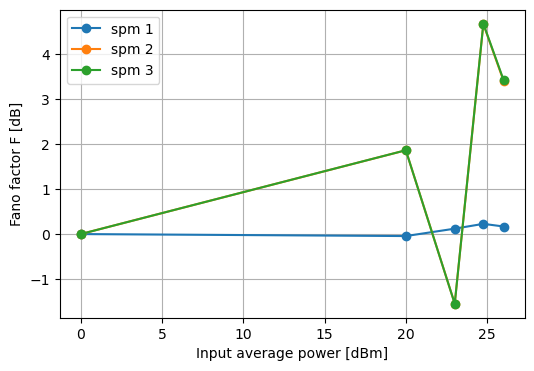

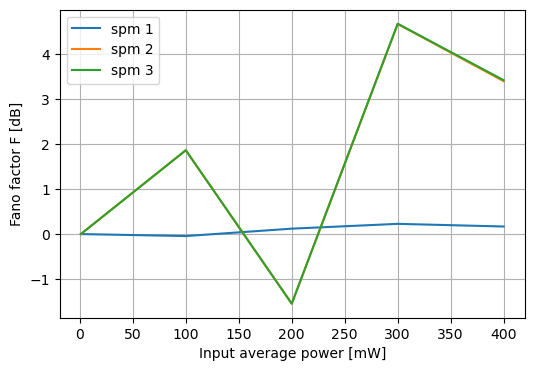

In [8]:
### plotting Fano factors [dB] vs. P_input [dBm]
figure(figsize=(6,4))
for m in 1:size(F, 2)
    plot(MultiModeNoise.lin_to_dB.(P_cont_set/1e-3), F[:, m], "o-", label="spm $m")
end
xlabel("Input average power [dBm]")
ylabel("Fano factor F [dB]")
legend()
grid(true)

### plotting Fano factors [dB] vs. P_input [mW]
figure(figsize=(6,4))
for m in 1:size(F, 2)
    plot(P_cont_set*1e3, F[:, m], label="spm $m")
end
xlabel("Input average power [mW]")
ylabel("Fano factor F [dB]")
legend()
grid(true)
# ylim(-5, 0)

show()

# to dos: save u0_modes as well; save in between loops w "for m in ..."

In [ ]:
### saving F vs. P data to .csv file
# using Pkg; Pkg.add("CSV"); Pkg.add("DataFrames"); Pkg.add("Dates") # if not installed
using CSV, DataFrames, Dates

df = DataFrame(power_mw = P_cont_set*1e3) # ensure array, convert to mW
for m in 1:M
    df[!, Symbol("F_spm_$(m)_db")] = F[:,m]
end

path = "\\\\files.cornell.edu\\EN\\riveralab\\Data\\mmf-spmode-squeezing\\"
filename = path*Dates.format(Dates.now(), "yymmdd_")*"data_f_vs_p_0-400mw_$(M)modes.csv" # full filename (path, file)
write(filename, @sprintf("spm_input = %s\n", round.(u0_modes, digits=3)))
CSV.write(filename, df, append=true) # save to .csv
# df2 = CSV.read("F_vs_P.csv", DataFrame)        # read back to verify
# P_loaded_mW = df2.Power_mW
# F_loaded = Matrix(df2[:, 2:end])
# println("Wrote and read back: ", size(df2), "  (rows,cols)")

"\\\\files.cornell.edu\\EN\\riveralab\\Data\\mmf-spmode-squeezing\\251124_data_f_vs_p_0-400mW_10modes.csv"

In [16]:
using Dates
Dates.format(Dates.now(), "yymmdd_")

"251120_"

In [10]:
using Pkg; Pkg.status()

Project MultiModeNoise v1.0.0-DEV
Status `C:\Users\EN-AEP-RiveraLab\Documents\Code sanctuary\dk932\mmf-spmode-squeezing\Project.toml`
  [7d9fca2a] Arpack v0.5.4
  [336ed68f] CSV v0.10.15
  [a93c6f00] DataFrames v1.8.1
  [0c46a032] DifferentialEquations v7.17.0
  [7a1cc6ca] FFTW v1.10.0
  [26cc04aa] FiniteDifferences v0.12.33
  [bdcacae8] LoopVectorization v0.12.173
  [15e1cf62] NPZ v0.4.3
  [d330b81b] PyPlot v2.11.6
  [bc48ee85] Tullio v0.3.8
  [37e2e46d] LinearAlgebra v1.12.0
  [2f01184e] SparseArrays v1.12.0


In [ ]:
LinRange(0, 1, 2)

2-element LinRange{Float64, Int64}:
 0.0, 1.0

In [19]:
@sprintf("spm_input = %s", round.(u0_modes, digits=3))

"spm_input = [0.136, -0.953, 0.272]"